# Phân tích Khám phá Dữ liệu (EDA) & Kiểm định Quy mô Chuỗi Thời gian 15-phút

Notebook này thực hiện quy trình kiểm định chất lượng dữ liệu và tiền xử lý trực quan đối với chuỗi thời gian 15-phút (**BTCUSDT_15m_raw.csv**) trước khi chuyển giao vào Dataset của PyTorch.

Quy trình được thực hiện qua **13 tiêu chí kiểm định nghiêm ngặt**, tập trung vào **trực quan hóa bằng đồ thị (Visualization)**, hạn chế tối đa việc sử dụng bảng và log thô.

## Bước 1: Thiết lập Thư viện & Cấu hình Đồ họa

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

## Bước 2: [Kiểm định 1 & 2] Đọc Dữ liệu, Kiểm tra Schema & Kiểu Dữ liệu

Chúng ta nạp tệp dữ liệu chuỗi thời gian 15-phút, thực hiện chuyển đổi kiểu dữ liệu (`date` sang `datetime`, các cột khác sang dạng số), và trực quan hóa tính đầy đủ của schema.

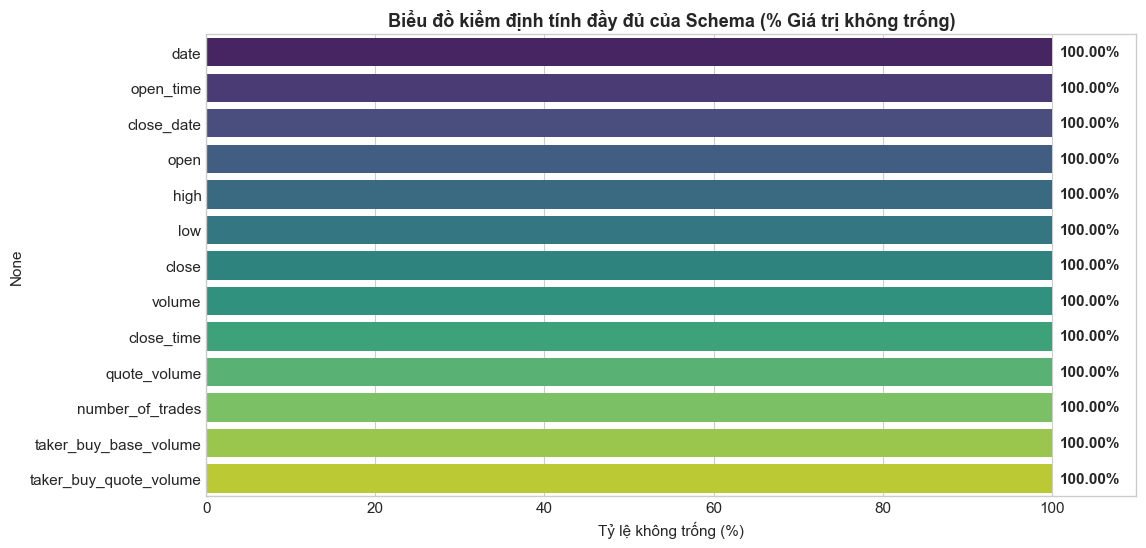

In [2]:
# Đường dẫn dữ liệu tuyệt đối
data_path = r"C:\Users\USER\Desktop\time_series\LLM for timeseries\LLMsForTimeSeries\CALF\dataset\raw\BTCUSDT_15m_raw.csv"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Không tìm thấy tệp dữ liệu tại {data_path}")

df = pd.read_csv(data_path)

# Chuyển đổi date thành DatetimeIndex (UTC)
df['date'] = pd.to_datetime(df['date'])
df['close_date'] = pd.to_datetime(df['close_date'])

# Ép kiểu các cột còn lại thành kiểu số
numeric_cols = [
    'open', 'high', 'low', 'close', 'volume', 
    'quote_volume', 'number_of_trades', 
    'taker_buy_base_volume', 'taker_buy_quote_volume'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Trực quan hóa phần trăm dữ liệu không bị khuyết để xác nhận schema
non_null_pct = df.notnull().mean() * 100

plt.figure(figsize=(12, 6))
sns.barplot(x=non_null_pct.values, y=non_null_pct.index, palette='viridis', hue=non_null_pct.index, legend=False)
plt.title('Biểu đồ kiểm định tính đầy đủ của Schema (% Giá trị không trống)', fontsize=13, fontweight='bold')
plt.xlabel('Tỷ lệ không trống (%)')
plt.xlim(0, 110)
for idx, val in enumerate(non_null_pct.values):
    plt.text(val + 1, idx, f"{val:.2f}%", va='center', fontweight='bold')
plt.show()

## Bước 3: [Kiểm định 2.5] Trực quan hóa Biến động Chuỗi Thời gian (Macro & Micro)

Vẽ xu hướng dài hạn (Macro) của giá đóng cửa đóng gói theo ngày, kết hợp phóng to phân khúc vi mô (Micro 500 nến) hiển thị đầy đủ OHLC để dễ dàng phân tích không bị chồng chéo.

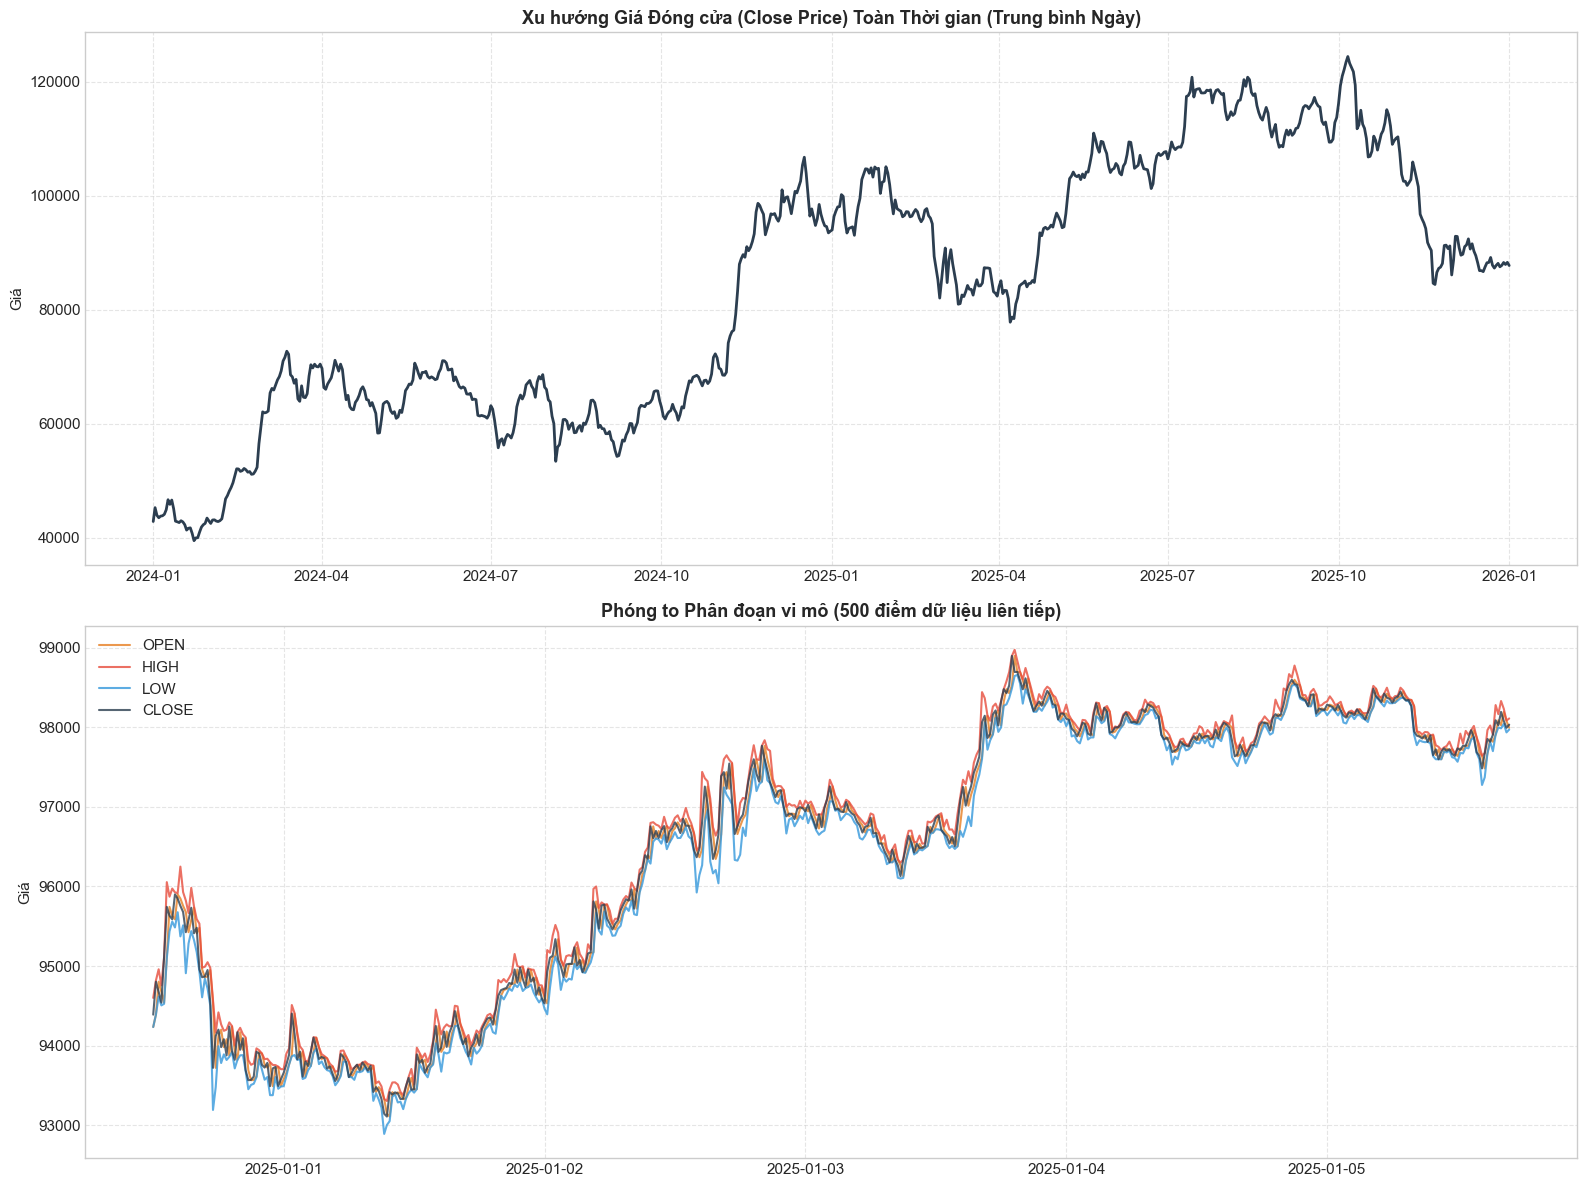

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# 1. Macro Trend (Giá trung bình theo ngày để tránh rối mắt)
df_daily = df.resample('1D', on='date')['close'].mean().reset_index()
axes[0].plot(df_daily['date'], df_daily['close'], color='#2c3e50', linewidth=2)
axes[0].set_title('Xu hướng Giá Đóng cửa (Close Price) Toàn Thời gian (Trung bình Ngày)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Giá')
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Micro Trend (500 điểm ở giữa chuỗi để xem chi tiết OHLC không bị lag)
mid_idx = len(df) // 2
df_micro = df.iloc[mid_idx:mid_idx + 500].copy()
color_map = {'open': '#e67e22', 'high': '#e74c3c', 'low': '#3498db', 'close': '#2c3e50'}
for col in ['open', 'high', 'low', 'close']:
    axes[1].plot(df_micro['date'], df_micro[col], label=col.upper(), color=color_map[col], alpha=0.8, linewidth=1.5)
axes[1].set_title('Phóng to Phân đoạn vi mô (500 điểm dữ liệu liên tiếp)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Giá')
axes[1].legend(loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Bước 4: [Kiểm định 3 & 4] Kiểm tra Timestamp Tăng dần, Không trùng lặp & Khoảng cách 15-phút

Ta kiểm tra tính tăng dần (Monotonic) của thời gian, tính độc nhất (không trùng lặp) và trực quan hóa khoảng cách thời gian giữa hai bản ghi liên tiếp để chứng minh lưới thời gian đạt chuẩn 15-phút.

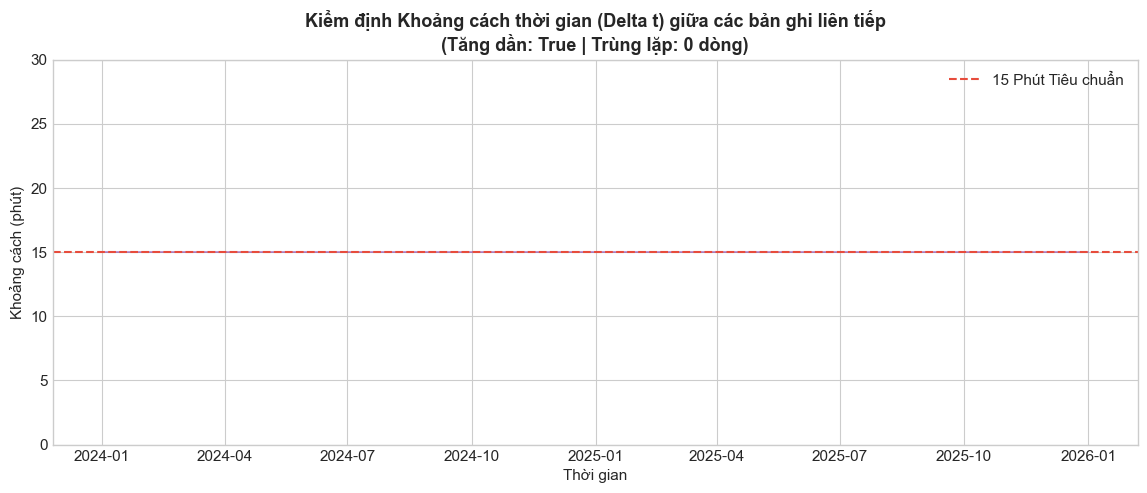

In [4]:
# Sắp xếp dữ liệu theo timestamp
df = df.sort_values('date').reset_index(drop=True)
is_monotonic = df['date'].is_monotonic_increasing
dup_count = df['date'].duplicated().sum()

# Tính toán delta t giữa các dòng liên tiếp (đơn vị: phút)
time_deltas = df['date'].diff().dt.total_seconds() / 60.0

# Trực quan hóa khoảng cách thời gian
plt.figure(figsize=(14, 5))
plt.plot(df['date'][1:], time_deltas[1:], color='#8e44ad', alpha=0.8, linewidth=1)
plt.axhline(15, color='#e74c3c', linestyle='--', linewidth=1.5, label='15 Phút Tiêu chuẩn')
plt.title(f'Kiểm định Khoảng cách thời gian (Delta t) giữa các bản ghi liên tiếp\n(Tăng dần: {is_monotonic} | Trùng lặp: {dup_count} dòng)', fontsize=13, fontweight='bold')
plt.ylabel('Khoảng cách (phút)')
plt.xlabel('Thời gian')
plt.ylim(0, 30)
plt.legend(loc='upper right')
plt.show()

## Bước 5: [Kiểm định 5] Kiểm tra Các Giá trị Khuyết thiếu (Missing Values)

Trực quan hóa sự xuất hiện của giá trị khuyết thiếu (`NaN`) trên toàn bộ các cột dữ liệu bằng Heatmap.

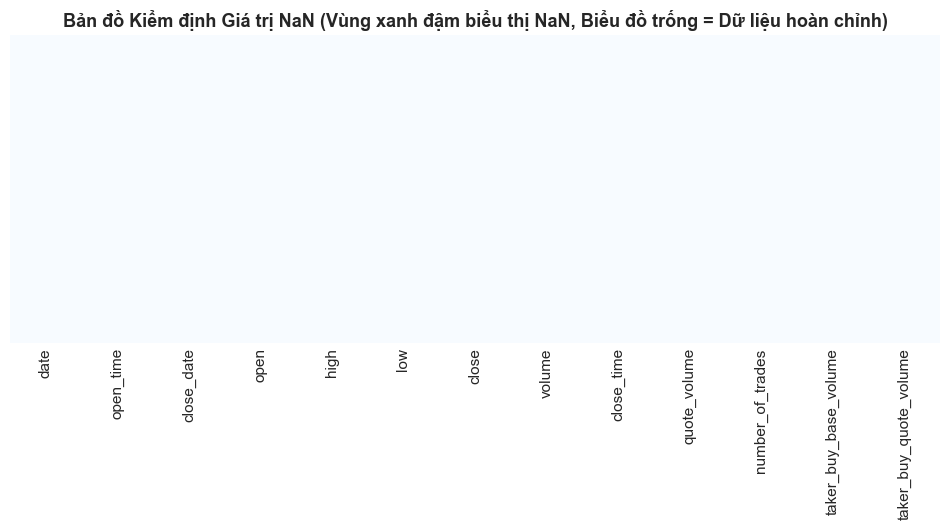

In [5]:
# Vẽ Heatmap khuyết thiếu
plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Blues')
plt.title('Bản đồ Kiểm định Giá trị NaN (Vùng xanh đậm biểu thị NaN, Biểu đồ trống = Dữ liệu hoàn chỉnh)', fontsize=13, fontweight='bold')
plt.show()

## Bước 6: [Kiểm định 6 & 7] Kiểm định Tính Hợp lệ của Giá OHLC & Khối lượng (Volume)

Chúng ta xác minh các quy tắc ràng buộc logic tài chính:
1. **OHLC**: $High \ge Open$, $High \ge Close$, $High \ge Low$, $Low \le Open$, $Low \le Close$.
2. **Volume & Trades**: $Volume \ge 0$, $Quote Volume \ge 0$, $Number of Trades \ge 0$.

Trực quan hóa dưới dạng biểu đồ thanh ngang hiển thị tỷ lệ đạt chuẩn của từng quy tắc.

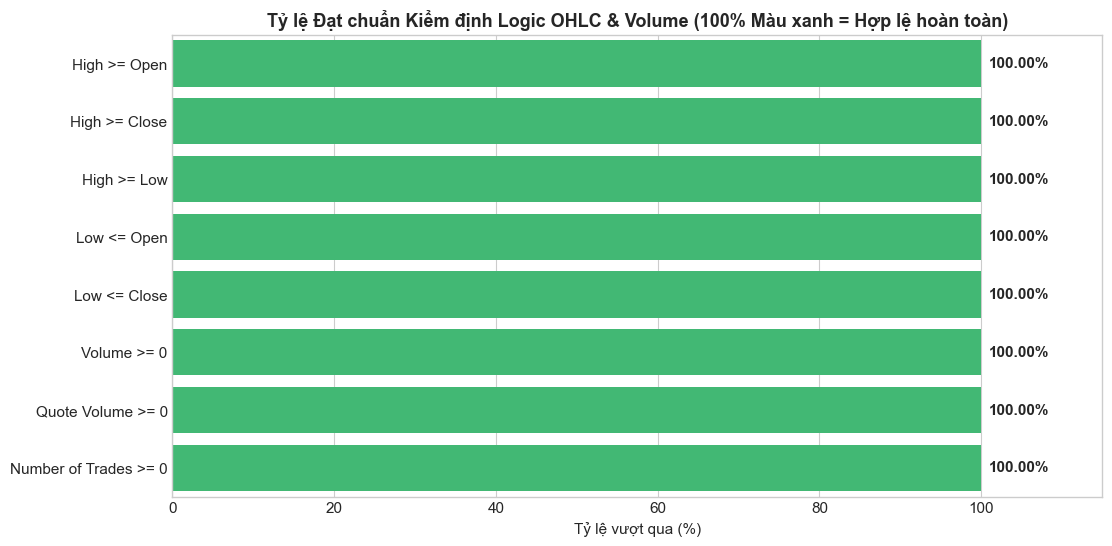

In [6]:
# Tính toán tỷ lệ phần trăm các dòng đạt chuẩn
check_high_open = (df['high'] >= df['open']).mean() * 100
check_high_close = (df['high'] >= df['close']).mean() * 100
check_high_low = (df['high'] >= df['low']).mean() * 100
check_low_open = (df['low'] <= df['open']).mean() * 100
check_low_close = (df['low'] <= df['close']).mean() * 100

check_vol = (df['volume'] >= 0).mean() * 100
check_qvol = (df['quote_volume'] >= 0).mean() * 100
check_trades = (df['number_of_trades'] >= 0).mean() * 100

rules = [
    'High >= Open', 'High >= Close', 'High >= Low',
    'Low <= Open', 'Low <= Close',
    'Volume >= 0', 'Quote Volume >= 0', 'Number of Trades >= 0'
]
rates = [
    check_high_open, check_high_close, check_high_low,
    check_low_open, check_low_close,
    check_vol, check_qvol, check_trades
]

# Tạo biểu đồ
plt.figure(figsize=(12, 6))
colors = ['#2ecc71' if x == 100.0 else '#e74c3c' for x in rates]
sns.barplot(x=rates, y=rules, palette=colors, hue=rules, legend=False)
plt.title('Tỷ lệ Đạt chuẩn Kiểm định Logic OHLC & Volume (100% Màu xanh = Hợp lệ hoàn toàn)', fontsize=13, fontweight='bold')
plt.xlabel('Tỷ lệ vượt qua (%)')
plt.xlim(0, 115)
for idx, val in enumerate(rates):
    plt.text(val + 1, idx, f"{val:.2f}%", va='center', fontweight='bold')
plt.show()

## Bước 7: [Kiểm định 8] Phân tích Phân phối Dữ liệu (Volume Skewness & Price Trend)

Kiểm tra xem thuộc tính `Volume` có phân phối lệch (skewed) mạnh không bằng biểu đồ KDE mật độ và Box Plot. Đồng thời biểu diễn xu hướng dài hạn của thuộc tính `Close` có kèm theo đường Moving Average (SMA 50 và 200 ngày) để xác minh tính định hướng (Trend).

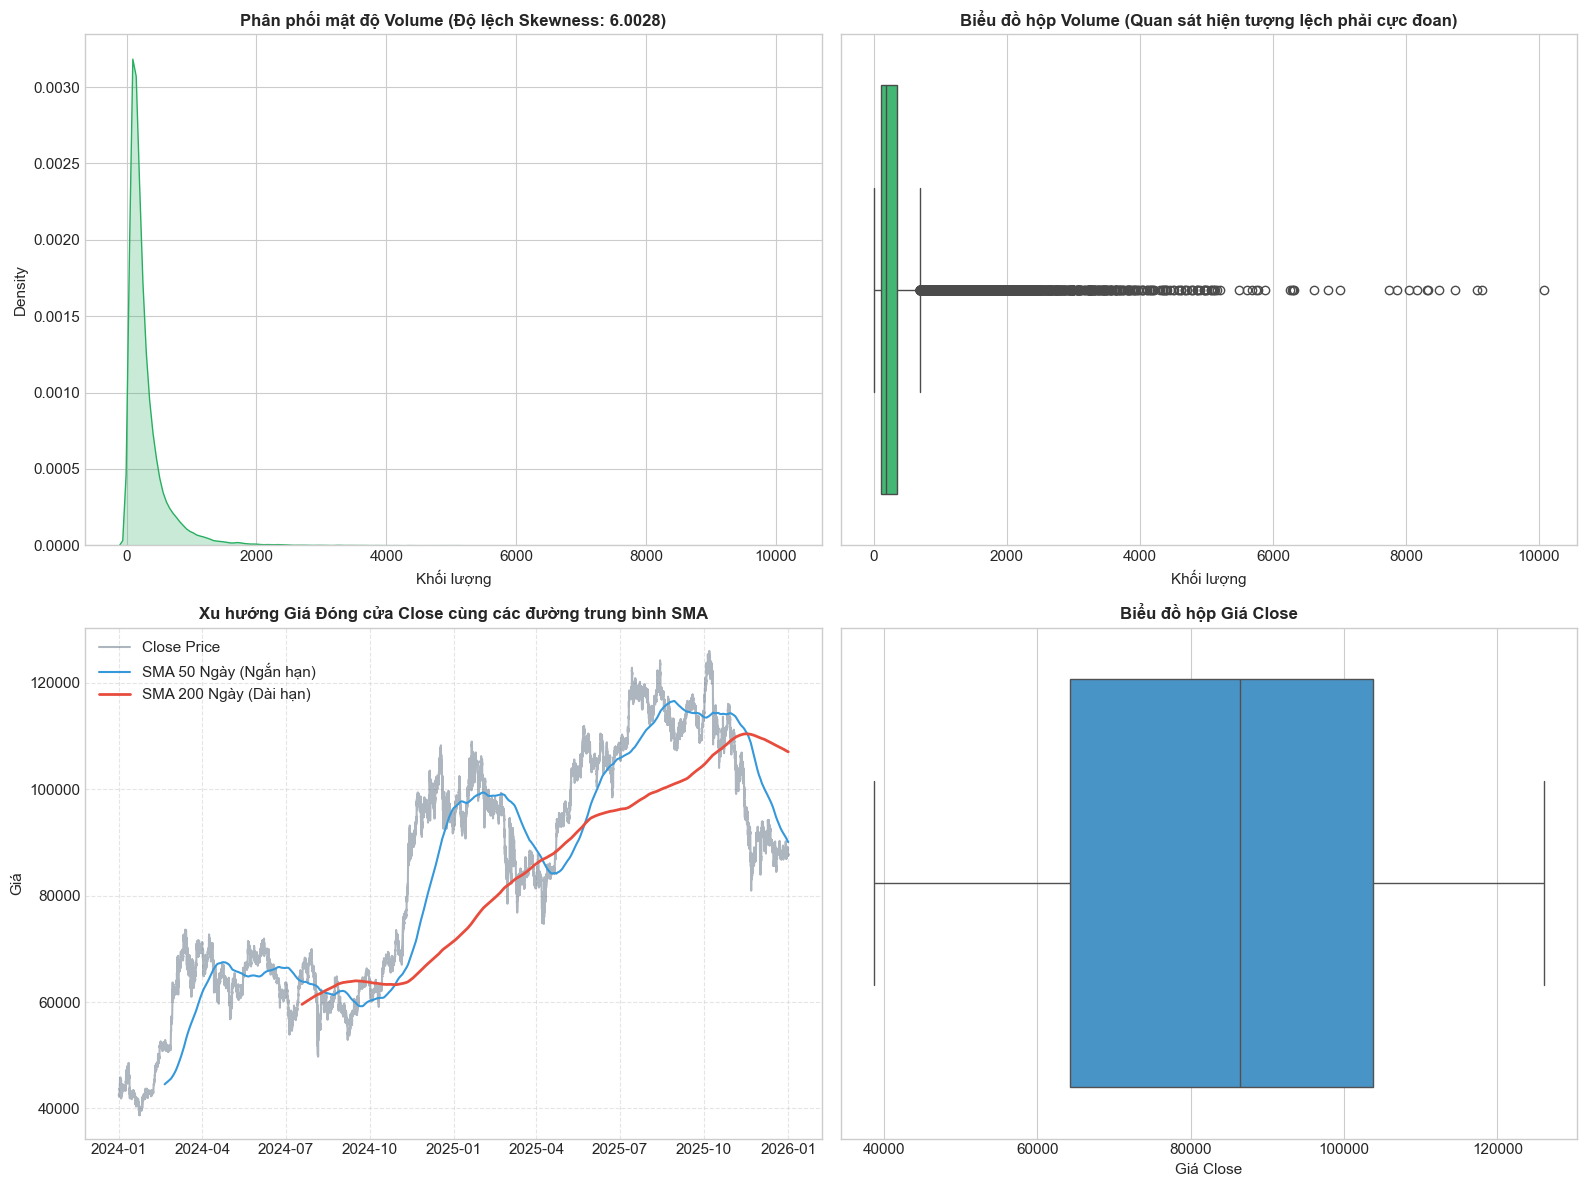

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Đồ thị phân phối KDE của Volume
sns.kdeplot(df['volume'], color='#27ae60', fill=True, ax=axes[0, 0])
axes[0, 0].set_title(f'Phân phối mật độ Volume (Độ lệch Skewness: {df["volume"].skew():.4f})', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Khối lượng')

# 2. Biểu đồ hộp Box plot của Volume để xem phân phối lệch phải (Outliers)
sns.boxplot(x=df['volume'], color='#2ecc71', ax=axes[0, 1])
axes[0, 1].set_title('Biểu đồ hộp Volume (Quan sát hiện tượng lệch phải cực đoan)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Khối lượng')

# Tính toán SMA 50 và 200 ngày (tần suất 15 phút, 1 ngày có 96 bản ghi)
df['SMA_50'] = df['close'].rolling(window=50*96).mean()
df['SMA_200'] = df['close'].rolling(window=200*96).mean()

# 3. Giá Close kết hợp SMA
axes[1, 0].plot(df['date'], df['close'], color='#34495e', alpha=0.4, label='Close Price')
axes[1, 0].plot(df['date'], df['SMA_50'], color='#3498db', label='SMA 50 Ngày (Ngắn hạn)', linewidth=1.5)
axes[1, 0].plot(df['date'], df['SMA_200'], color='#e74c3c', label='SMA 200 Ngày (Dài hạn)', linewidth=2)
axes[1, 0].set_title('Xu hướng Giá Đóng cửa Close cùng các đường trung bình SMA', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Giá')
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.5)

# 4. Biểu đồ hộp của Close
sns.boxplot(x=df['close'], color='#3498db', ax=axes[1, 1])
axes[1, 1].set_title('Biểu đồ hộp Giá Close', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Giá Close')

plt.tight_layout()
plt.show()

## Bước 8: [Kiểm định 9] Ma trận Tương quan Pearson (Pearson Correlation)

Chúng ta tính toán ma trận Pearson giữa các chiều thuộc tính số chính. Ràng buộc OHLC sẽ có tương quan cực cao (xấp xỉ 1.0) và đây là hiện tượng bình thường trong phân tích tài chính kỹ thuật.

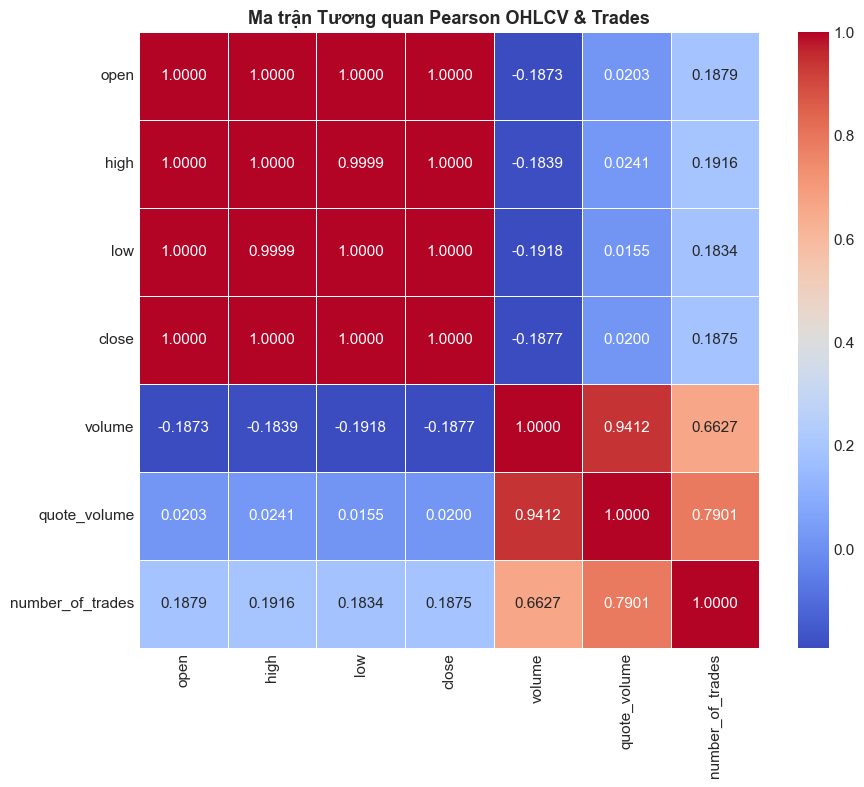

In [8]:
ohlcv_features = ['open', 'high', 'low', 'close', 'volume', 'quote_volume', 'number_of_trades']
corr_matrix = df[ohlcv_features].corr(method='pearson')

# Vẽ ma trận trực quan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5)
plt.title('Ma trận Tương quan Pearson OHLCV & Trades', fontsize=13, fontweight='bold')
plt.show()

## Bước 9: [Kiểm định 10] Trực quan hóa Phóng to Toàn bộ 9 Đặc trưng Hệ thống (Zoom-in Standardized Features Overlay)

Để so sánh hình dáng, tương quan động và biến động vi mô của **toàn bộ 9 chiều đặc trưng số** cùng một lúc trên một đồ thị đường duy nhất, chúng ta trích xuất **50 điểm dữ liệu liên tiếp** và áp dụng kỹ thuật chuẩn hóa **Min-Max Scaling** đưa toàn bộ các cột về khoảng $[0, 1]$.

Điều này giải quyết triệt để sự lệch thang đo cực đoan giữa giá (chục nghìn USD) và khối lượng/số lượng giao dịch, đem lại biểu đồ đối chiếu vi mô sắc nét.

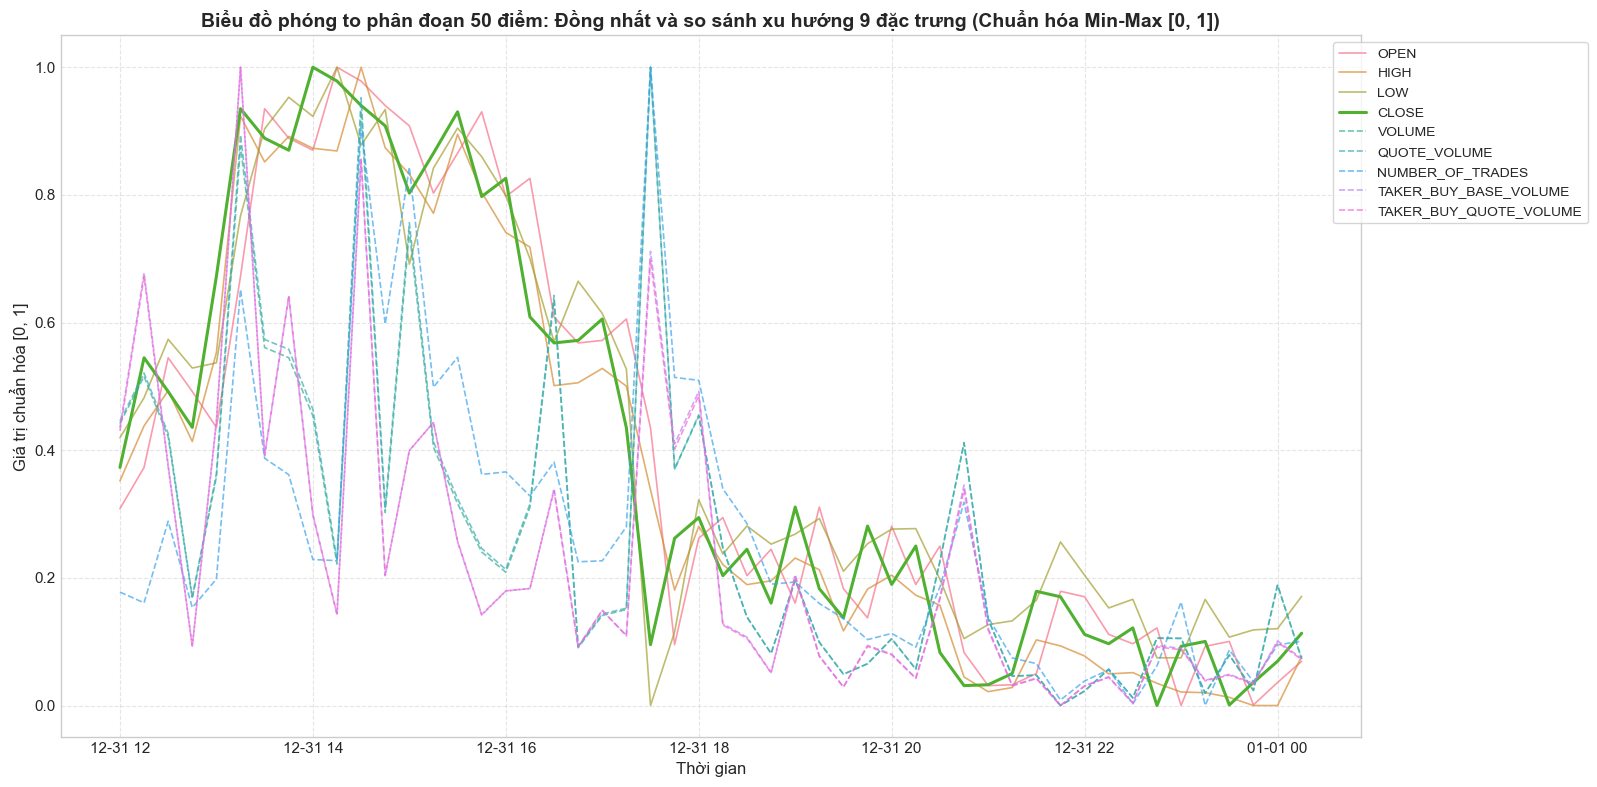

In [9]:
# Trích xuất 50 điểm dữ liệu liên tiếp ở giữa chuỗi
zoom_start = len(df) // 2
zoom_end = zoom_start + 50
df_zoom = df.iloc[zoom_start:zoom_end].copy()

# Danh sách 9 đặc trưng cần so sánh đồng thời
all_9_features = [
    'open', 'high', 'low', 'close', 'volume', 
    'quote_volume', 'number_of_trades', 
    'taker_buy_base_volume', 'taker_buy_quote_volume'
]

# Thực hiện chuẩn hóa Min-Max riêng cho phân đoạn zoom
df_zoom_scaled = df_zoom.copy()
for feature in all_9_features:
    f_min = df_zoom[feature].min()
    f_max = df_zoom[feature].max()
    if f_max - f_min > 0:
        df_zoom_scaled[feature] = (df_zoom[feature] - f_min) / (f_max - f_min)
    else:
        df_zoom_scaled[feature] = 0.5

# Trực quan hóa toàn bộ 9 đặc trưng đồng thời trên một biểu đồ đường
plt.figure(figsize=(16, 8))
colors = sns.color_palette("husl", len(all_9_features))

for idx, feature in enumerate(all_9_features):
    # Sử dụng nét liền cho giá (OHLC) và nét đứt cho các thuộc tính khối lượng/giao dịch bổ trợ
    linestyle = '-' if feature in ['open', 'high', 'low', 'close'] else '--'
    linewidth = 2.2 if feature == 'close' else 1.2
    alpha = 1.0 if feature == 'close' else 0.7
    
    plt.plot(df_zoom_scaled['date'], df_zoom_scaled[feature], 
             label=feature.upper(), color=colors[idx], 
             linestyle=linestyle, linewidth=linewidth, alpha=alpha)

plt.title('Biểu đồ phóng to phân đoạn 50 điểm: Đồng nhất và so sánh xu hướng 9 đặc trưng (Chuẩn hóa Min-Max [0, 1])', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Giá trị chuẩn hóa [0, 1]', fontsize=12)
plt.legend(loc='upper right', bbox_to_anchor=(1.18, 1.0), frameon=True, fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Bước 9.5: Tách riêng Đồ thị từng Đặc trưng số trong Phân đoạn Phóng to (Zoom-in Individual Features Subplots)

Để quan sát chi tiết biên dạng thực tế (ở đơn vị đo lường gốc) mà không bị che khuất lẫn nhau, chúng ta tách 9 đặc trưng số này ra thành **9 đồ thị xếp chồng** chung trục thời gian (`sharex=True`).

Mỗi đặc trưng được tô bằng **màu sắc tương phản đậm, rõ nét (Dark/Bold colors)** kết hợp phủ mờ nhẹ ở nền để tối đa hóa sự dễ nhìn.

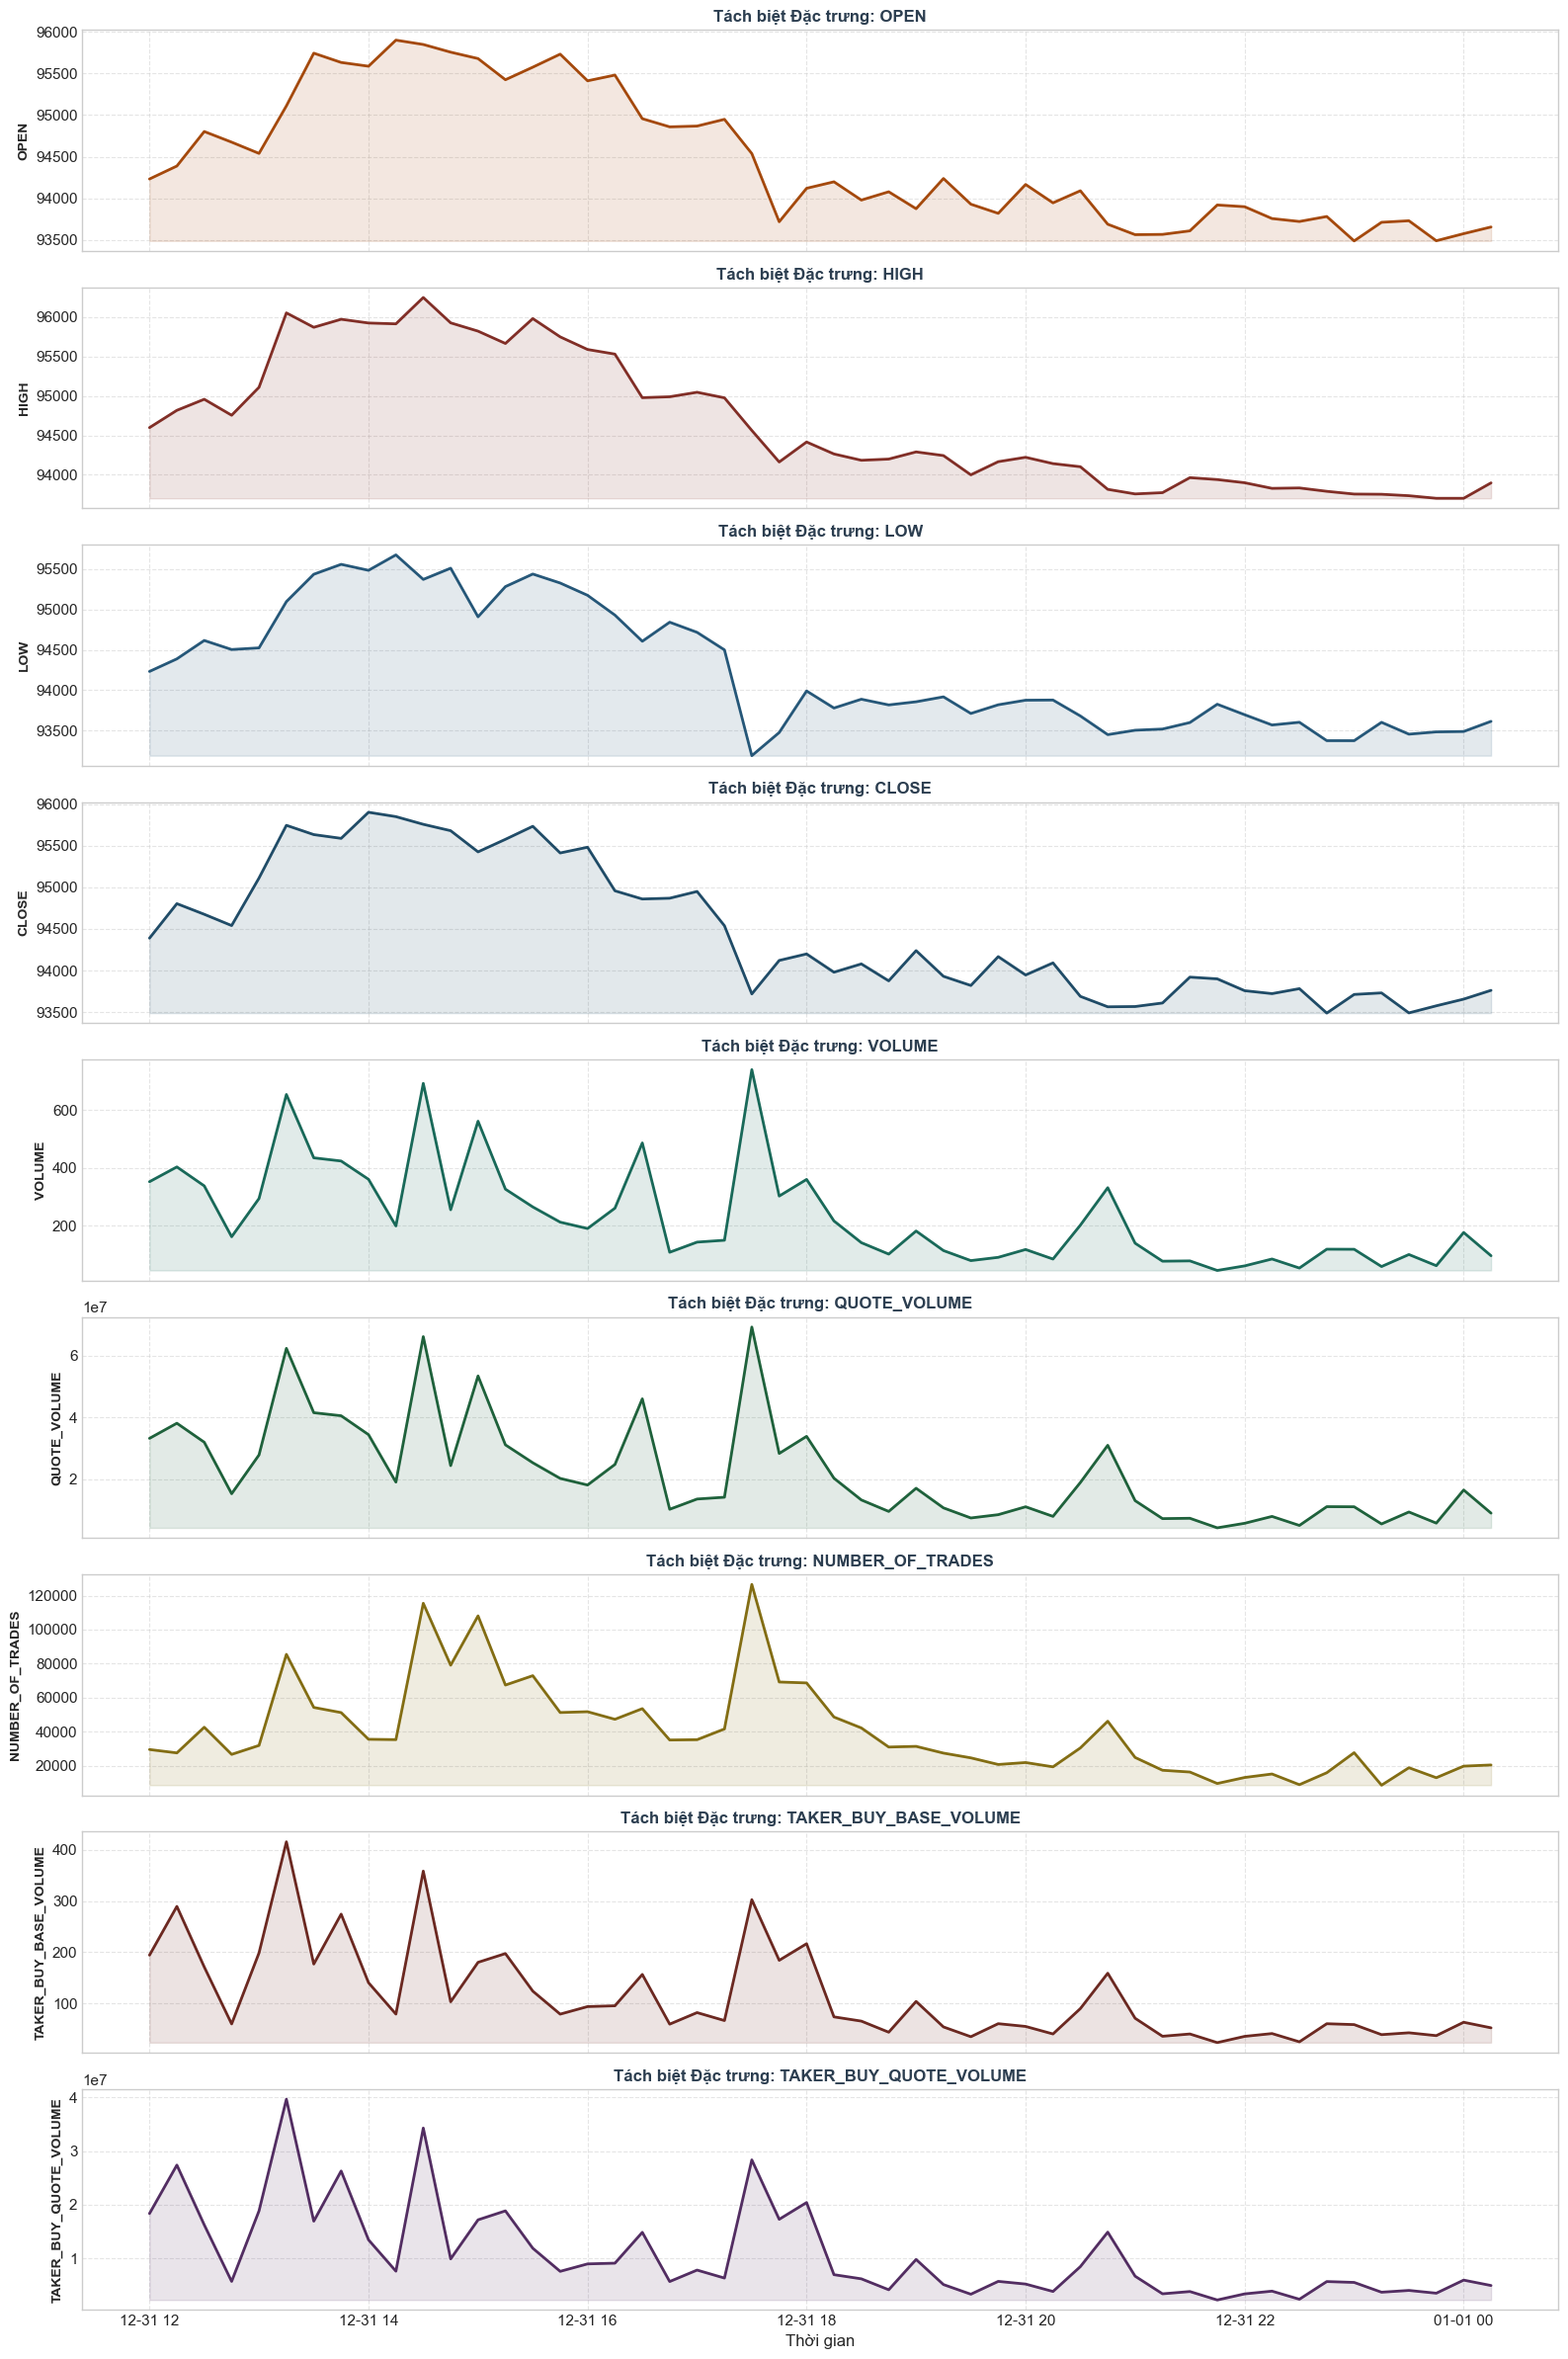

In [10]:
# Tạo 9 subplots xếp chồng dọc dùng chung trục hoành thời gian
fig, axes = plt.subplots(len(all_9_features), 1, figsize=(16, 24), sharex=True)

# Bảng màu đậm có độ tương phản cao
dark_bold_colors = [
    '#a04000', '#7b241c', '#1b4f72', '#154360', '#0e6251', 
    '#145a32', '#7d6608', '#641e16', '#4a235a'
]

for idx, feature in enumerate(all_9_features):
    # Vẽ từng biểu đồ đường độc lập với nét vẽ đậm (linewidth=2.0)
    axes[idx].plot(df_zoom['date'], df_zoom[feature], 
                  color=dark_bold_colors[idx], linewidth=2.0, alpha=0.95)
    
    axes[idx].set_title(f'Tách biệt Đặc trưng: {feature.upper()}', fontsize=12, fontweight='bold', color='#2c3e50')
    axes[idx].set_ylabel(feature.upper(), fontsize=10, fontweight='bold')
    axes[idx].grid(True, linestyle='--', alpha=0.5)
    
    # Tạo vùng phủ mờ nhẹ dưới đồ thị
    axes[idx].fill_between(df_zoom['date'], df_zoom[feature].min(), df_zoom[feature], 
                           color=dark_bold_colors[idx], alpha=0.12)

axes[-1].set_xlabel('Thời gian', fontsize=12)
plt.tight_layout()
plt.show()

## Bước 10: [Kiểm định 11] Phân rã Chuỗi Thời gian (Time Series Decomposition)

Trong phân tích kỹ thuật chuỗi thời gian, việc phân rã giúp bóc tách giá thực tế thành 3 thành phần có ý nghĩa:
1.  **Xu hướng (Trend)**: Hướng đi dài hạn của giá.
2.  **Mùa vụ/Chu kỳ (Seasonal)**: Sự dao động lặp đi lặp lại có chu kỳ cố định (ở đây tần suất 15 phút, chu kỳ ngày có chu kỳ cố định là **96 bản ghi mỗi ngày**).
3.  **Phần dư (Residual/Noise)**: Nhiễu ngẫu nhiên còn lại.

Chúng ta trích xuất **1,000 điểm dữ liệu liên tiếp** (tương đương hơn 10 ngày giao dịch liên tục) và thực hiện thuật toán phân rã cộng tính (`additive`) để trực quan hóa rõ nét từng thành phần.

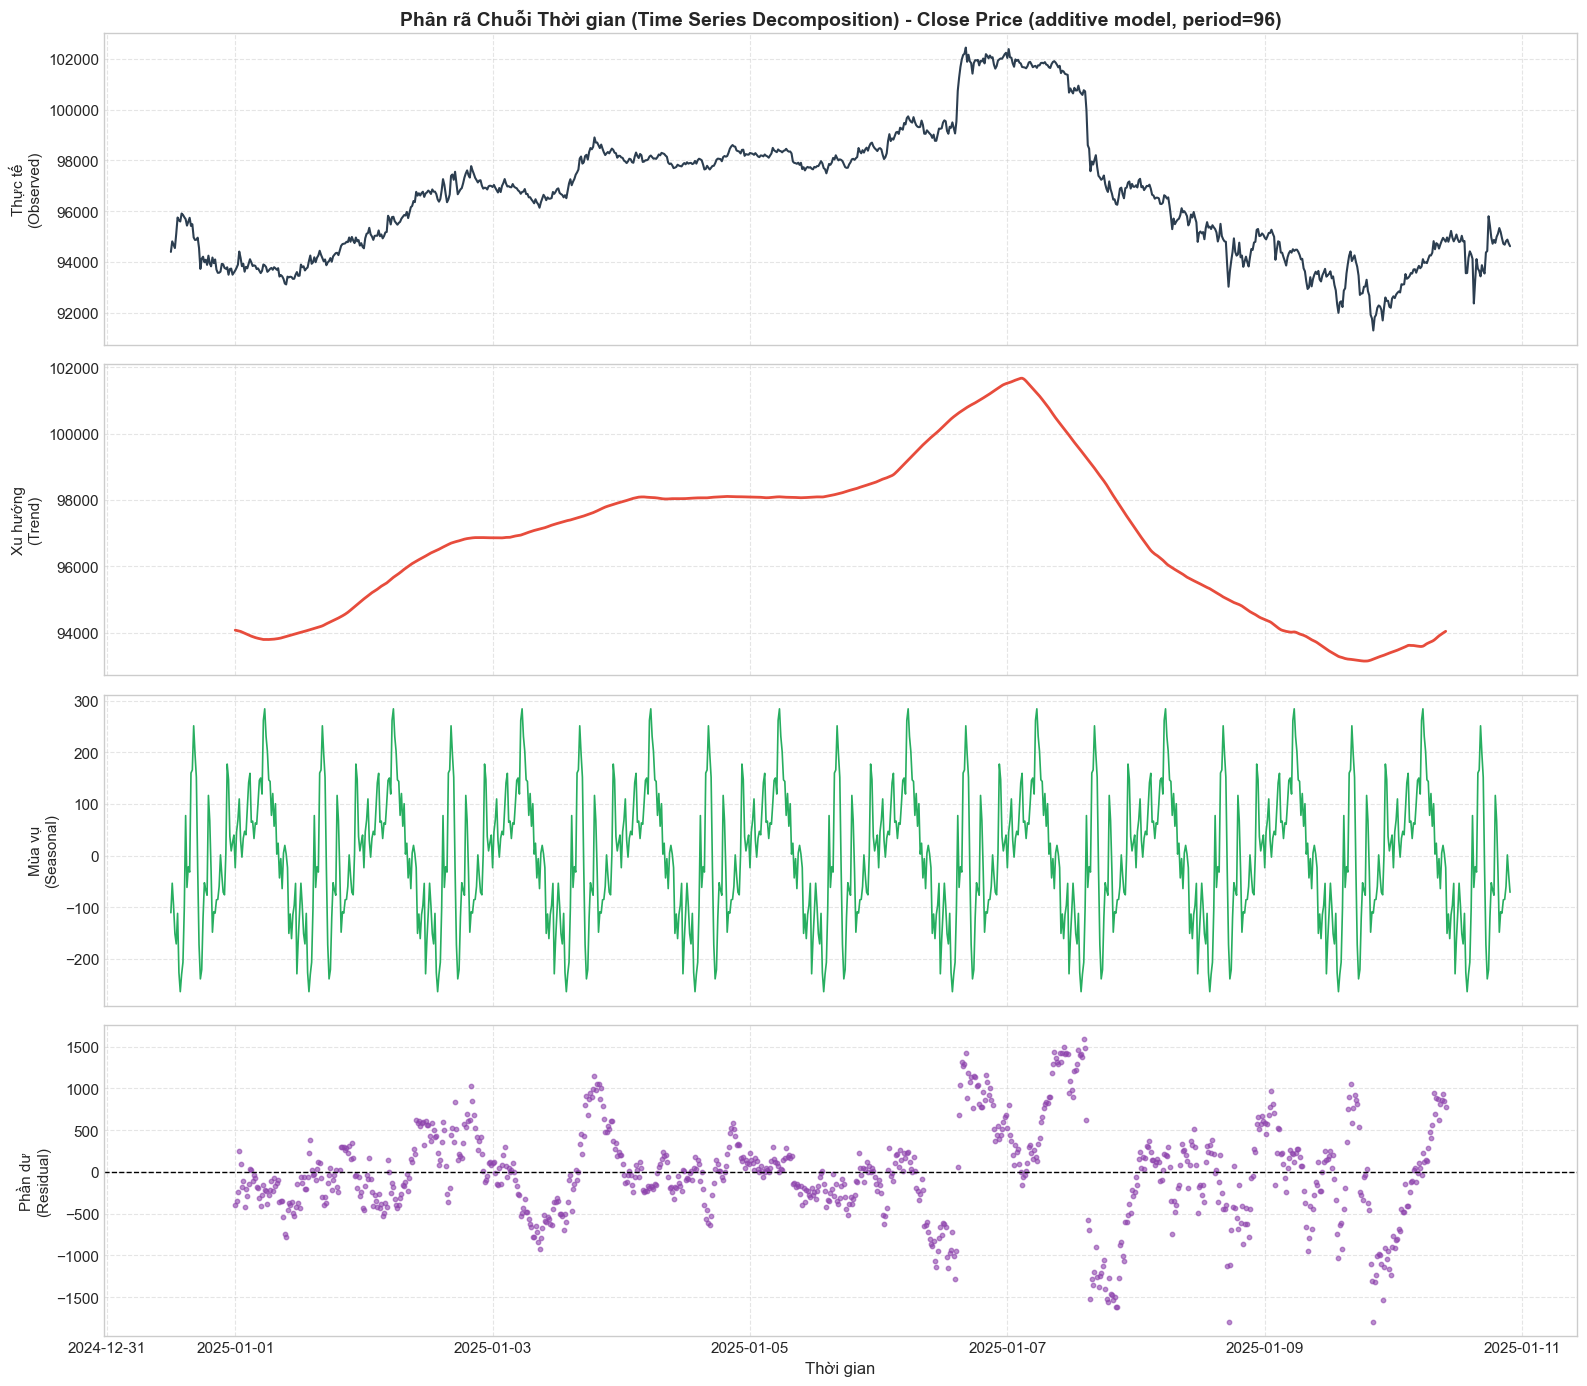

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Trích xuất phân đoạn 1000 điểm dữ liệu liên tiếp
df_decomp = df.iloc[mid_idx:mid_idx + 1000].copy()
df_decomp = df_decomp.set_index('date')

# Thực hiện phân rã cộng tính với chu kỳ ngày là 96 nến (1 ngày = 24h * 4 nến/h = 96 nến)
decomp_results = seasonal_decompose(df_decomp['close'], model='additive', period=96)

# Vẽ 4 biểu đồ con tương ứng dọc theo trục thời gian
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# 1. Observed (Giá thực tế)
axes[0].plot(df_decomp.index, decomp_results.observed, color='#2c3e50', linewidth=1.5)
axes[0].set_title('Phân rã Chuỗi Thời gian (Time Series Decomposition) - Close Price (additive model, period=96)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Thực tế\n(Observed)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Trend (Xu hướng dài hạn)
axes[1].plot(df_decomp.index, decomp_results.trend, color='#e74c3c', linewidth=2)
axes[1].set_ylabel('Xu hướng\n(Trend)', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Seasonal (Chu kỳ mùa vụ hàng ngày)
axes[2].plot(df_decomp.index, decomp_results.seasonal, color='#27ae60', linewidth=1.2)
axes[2].set_ylabel('Mùa vụ\n(Seasonal)', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.5)

# 4. Residual (Phần dư/Nhiễu)
axes[3].scatter(df_decomp.index, decomp_results.resid, color='#8e44ad', alpha=0.6, s=10)
axes[3].axhline(0, color='black', linestyle='--', linewidth=1)
axes[3].set_ylabel('Phần dư\n(Residual)', fontsize=11)
axes[3].set_xlabel('Thời gian', fontsize=12)
axes[3].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Bước 11: [Kiểm định 12] Kiểm định Phân vùng Thời gian (Train/Val/Test Splits)

Dữ liệu thời gian được chia tuần tự (không shuffle): **70% Train**, **15% Validation**, và **15% Test**.

Chúng ta chỉ trực quan hóa các đường ranh giới phân tách trên biểu đồ Close price để kiểm tra độ dài và vị trí biên của các tập dữ liệu, hoàn toàn không tự ý chia và tạo file độc lập ở bước này.

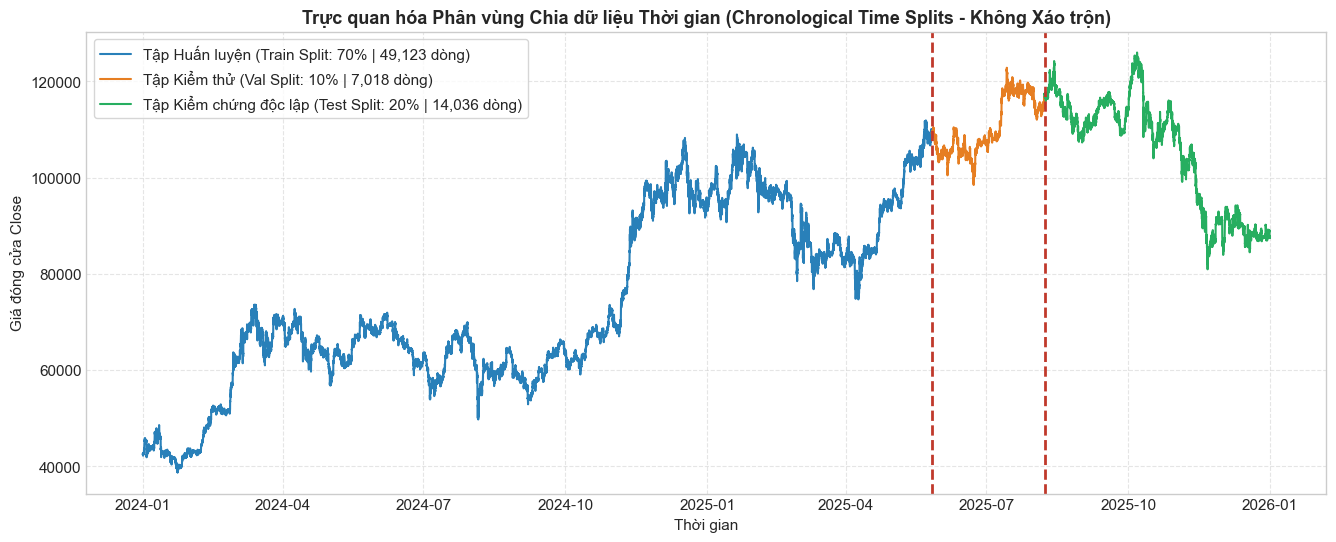

In [12]:
n_total = len(df)
train_boundary = int(n_total * 0.7)
val_boundary = int(n_total * 0.8)

# Vẽ biểu đồ phân tách các tập dữ liệu
plt.figure(figsize=(16, 6))
plt.plot(df['date'][:train_boundary], df['close'][:train_boundary], color='#2980b9', label=f'Tập Huấn luyện (Train Split: 70% | {train_boundary:,} dòng)')
plt.plot(df['date'][train_boundary:val_boundary], df['close'][train_boundary:val_boundary], color='#e67e22', label=f'Tập Kiểm thử (Val Split: 10% | {val_boundary-train_boundary:,} dòng)')
plt.plot(df['date'][val_boundary:], df['close'][val_boundary:], color='#27ae60', label=f'Tập Kiểm chứng độc lập (Test Split: 20% | {n_total-val_boundary:,} dòng)')

# Vẽ các đường ranh giới đỏ đứt nét để chỉ rõ biên thời gian
plt.axvline(df['date'].iloc[train_boundary], color='#c0392b', linestyle='--', linewidth=2)
plt.axvline(df['date'].iloc[val_boundary], color='#c0392b', linestyle='--', linewidth=2)

plt.title('Trực quan hóa Phân vùng Chia dữ liệu Thời gian (Chronological Time Splits - Không Xáo trộn)', fontsize=13, fontweight='bold')
plt.ylabel('Giá đóng cửa Close')
plt.xlabel('Thời gian')
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

ValueError: '' is not a valid value for color: supported inputs are (r, g, b) and (r, g, b, a) 0-1 float tuples; '#rrggbb', '#rrggbbaa', '#rgb', '#rgba' strings; named color strings; string reprs of 0-1 floats for grayscale values; 'C0', 'C1', ... strings for colors of the color cycle; and pairs combining one of the above with an alpha value

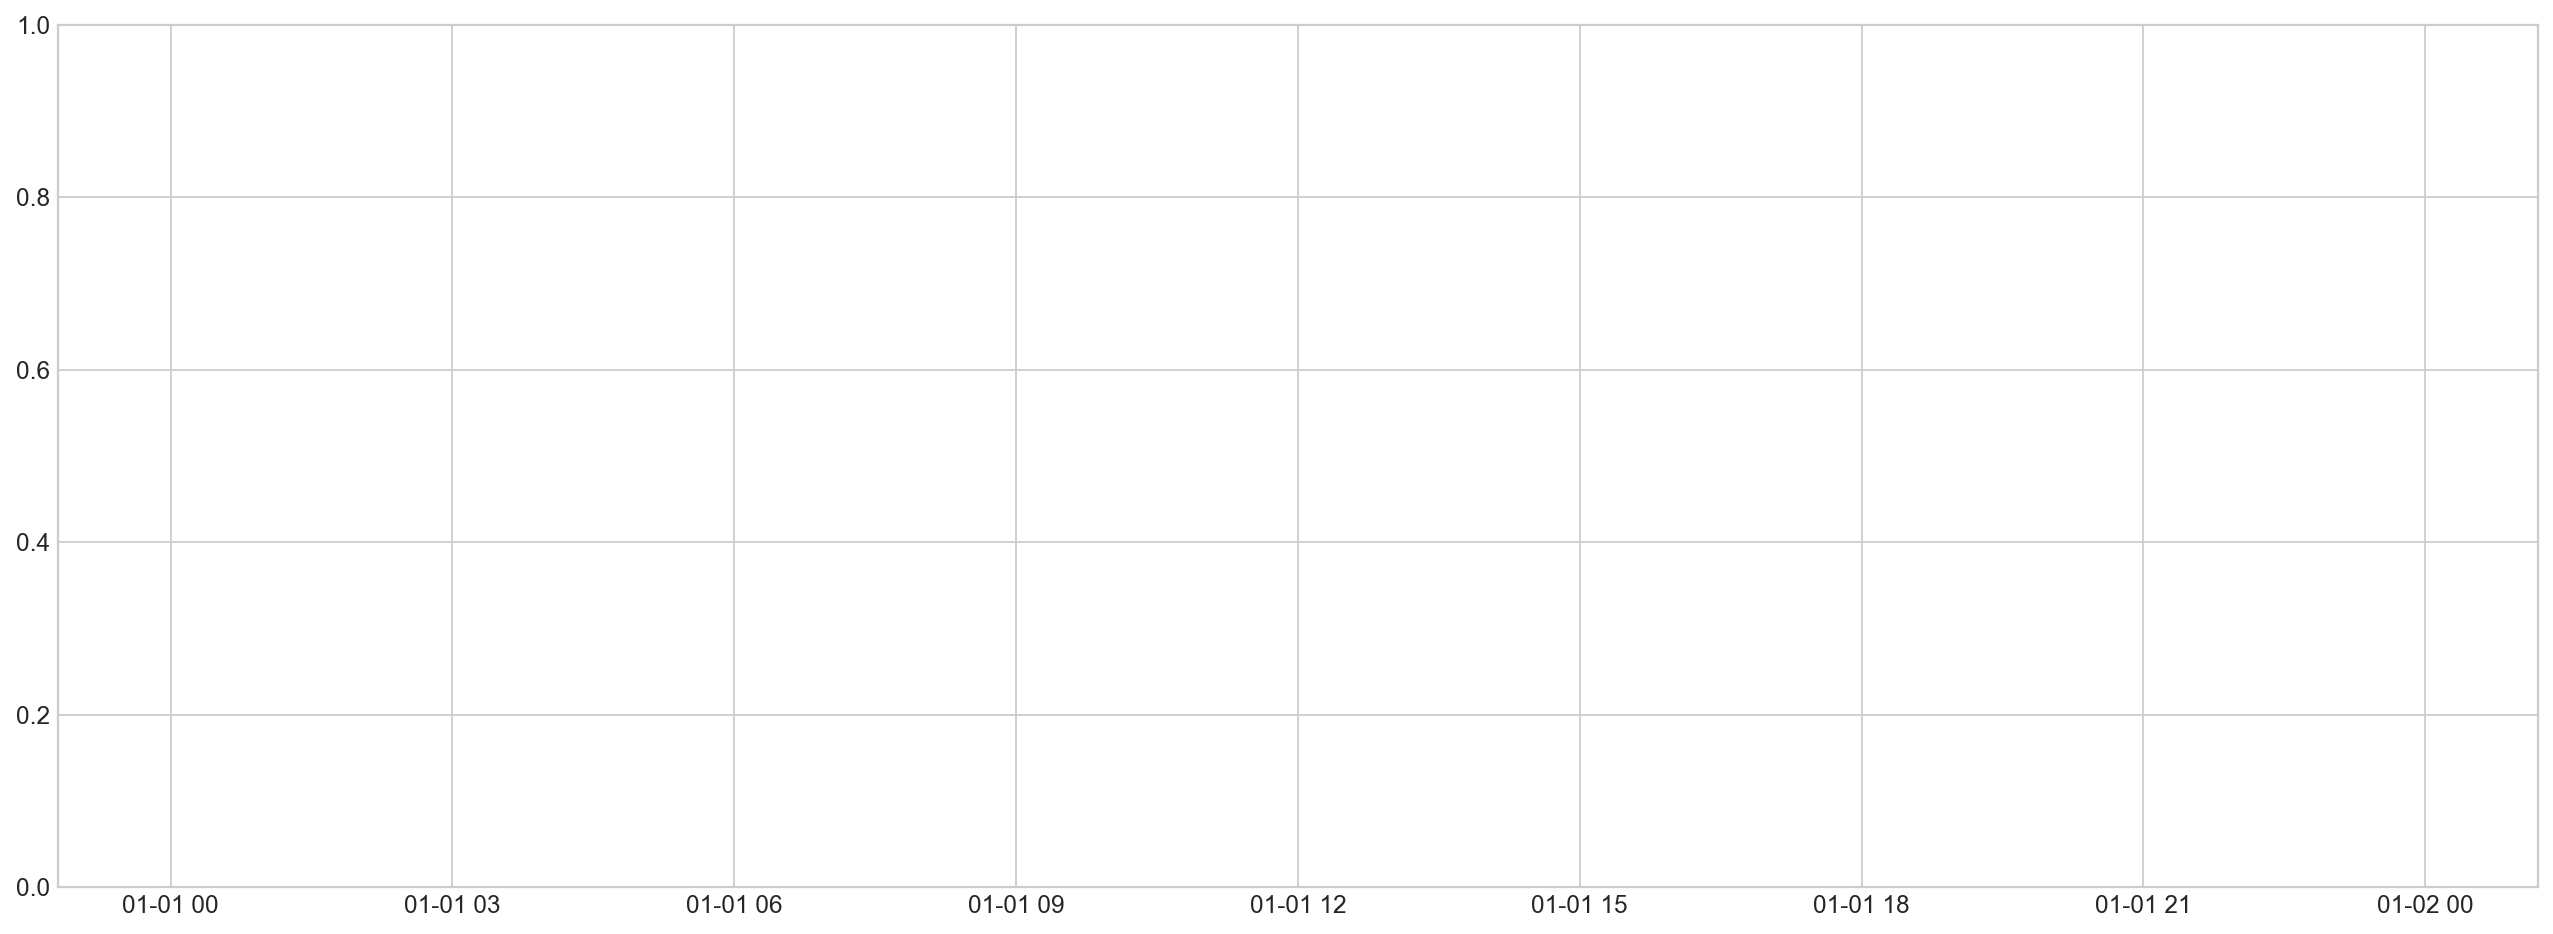

In [13]:
# Line plot chuoi thoi gian close trong 3 thang gan nhat
end_date = df['date'].max()
start_date = end_date - pd.DateOffset(days=5)
df_3m = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

plt.figure(figsize=(20, 7), dpi=160)
plt.plot(df_3m['date'], df_3m['close'], color='', linewidth=3)
plt.title(f'Chuoi thoi gian gia Close (3 thang gan nhat: {start_date.date()} -> {end_date.date()})', fontsize=14, fontweight='bold')
plt.xlabel('Thoi gian', fontsize=12)
plt.ylabel('Gia Close', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()